### 📊 Final Dashboard & Business KPIs

#### Objective

The purpose of this notebook is to summarize the business performance using key performance indicators (KPIs) and visual dashboards.

The metrics presented in this notebook provide an overview of customer behavior, revenue generation, purchasing patterns, and customer segmentation. These insights can help business stakeholders monitor performance and support data-driven decision making.

At the end of this notebook, a collection of business KPIs and visualizations will serve as an executive dashboard for the e-commerce business.


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import seaborn as sns

plt.style.use('ggplot')

In [28]:
customer_df = pd.read_csv('../data/processed/customer_final.csv')

In [29]:
# ==========================================
# Dashboard Theme
# ==========================================

PRIMARY_COLOR = '#2E8B57'
SECONDARY_COLOR = '#4CAF50'
WARNING_COLOR = '#FF9800'
DANGER_COLOR = '#F44336'
NEUTRAL_COLOR = '#9E9E9E'
BACKGROUND_COLOR = '#F8F9FA'

SEGMENT_COLORS = {
    'Champions': '#2E8B57',
    'Loyal Customer': '#4CAF50',
    'Potential Loyalists': '#AED581',
    'New Customer': '#03A9F4',
    'Cannot Lose Them': '#FF9800',
    'At Risk': '#F44336',
    'Hibernating': '#9E9E9E',
    'Lost': '#424242',
    'Others': '#BDBDBD'
}

plt.style.use('ggplot')

In [30]:
# HELPER FUNCTIONS

def format_number(num):

    if num >= 1_000_000:
        return f'${num/1_000_000:.2f}M'

    elif num >= 1_000:
        return f'${num/1_000:.1f}K'

    else:
        return f'${num:.0f}'



#### Dataset Overview

In [31]:
customer_df.shape

(5000, 11)

In [32]:
customer_df.head()

,Customer_ID,Frequency,Monetary,Recency,M_Score,R_Score,Frequency_Rank,F_Score,RFM_Score,RFM_Code,Segment
0,CUST_00001,3,2199.63,112,3,3,2147.0,3,9,333,Others
1,CUST_00002,2,809.90,284,2,1,893.0,1,4,112,Lost
2,CUST_00003,2,3030.81,83,3,3,894.0,1,7,313,Others
3,CUST_00004,1,383.22,42,1,4,1.0,1,6,411,New Customer
4,CUST_00005,3,2422.73,279,3,1,2148.0,3,7,133,At Risk


In [33]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     5000 non-null   object 
 1   Frequency       5000 non-null   int64  
 2   Monetary        5000 non-null   float64
 3   Recency         5000 non-null   int64  
 4   M_Score         5000 non-null   int64  
 5   R_Score         5000 non-null   int64  
 6   Frequency_Rank  5000 non-null   float64
 7   F_Score         5000 non-null   int64  
 8   RFM_Score       5000 non-null   int64  
 9   RFM_Code        5000 non-null   int64  
 10  Segment         5000 non-null   object 
dtypes: float64(2), int64(7), object(2)
memory usage: 429.8+ KB


### Customer Segment Distribution

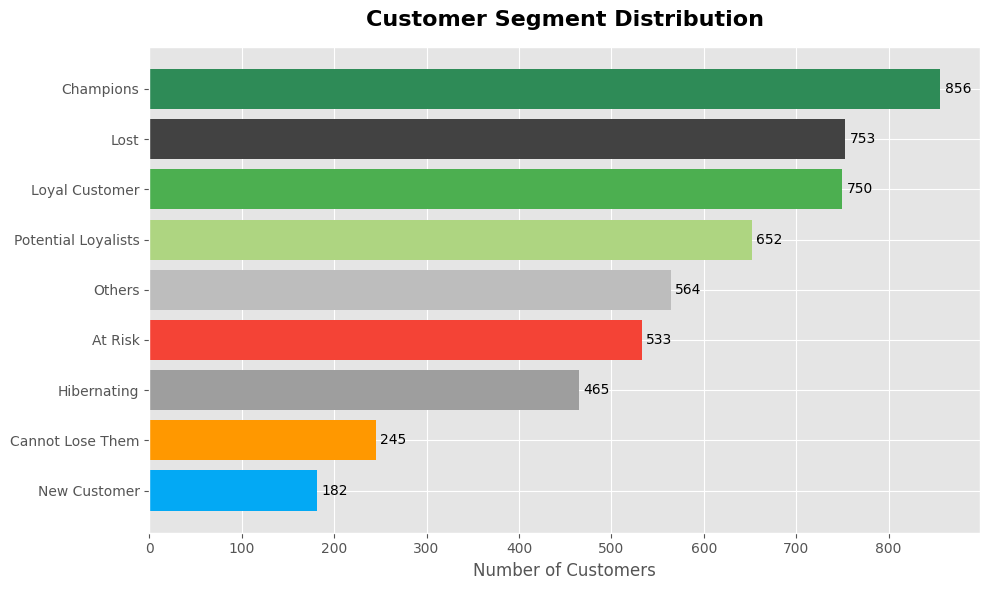

In [36]:
segment_count = (
    customer_df['Segment']
    .value_counts()
    .sort_values()
)



colors = [
    SEGMENT_COLORS[segment] for segment in segment_count.index
    ]

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    segment_count.index,
    segment_count.values,
    color=colors
)

# Add value labels
ax.bar_label(
    bars,
    padding=3,
    fontsize=10
)

ax.set_title(
    'Customer Segment Distribution',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Number of Customers')
ax.set_ylabel('')

plt.tight_layout()

plt.savefig(
    '../images/Customer_Segment_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Revenue by Customer Segment

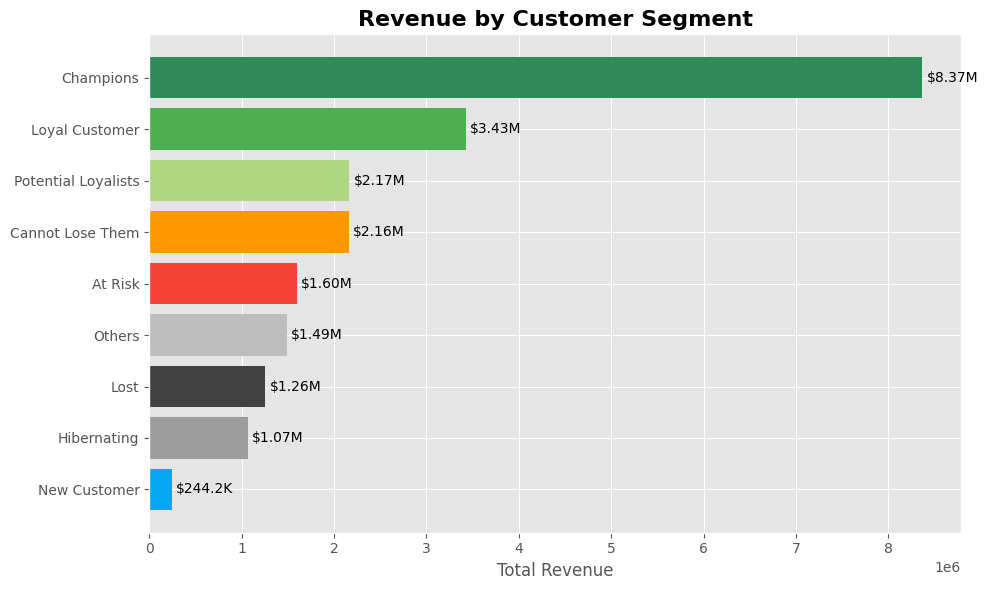

In [37]:
segment_revenue = (
    customer_df.groupby('Segment')['Monetary']
    .sum()
    .sort_values()
)

colors = [SEGMENT_COLORS[segment] for segment in segment_revenue.index]

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    segment_revenue.index,
    segment_revenue.values,
    color=colors
)



labels = [
    format_number(value)
    for value in segment_revenue.values
]

ax.bar_label(
    bars,
    labels=labels,
    padding=3,
    fontsize=10
)

ax.set_title(
    'Revenue by Customer Segment',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Total Revenue')
ax.set_ylabel('')

plt.tight_layout()

plt.savefig(
    '../images/Revenue by Customer Segment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Average RFM Metrics by Segment

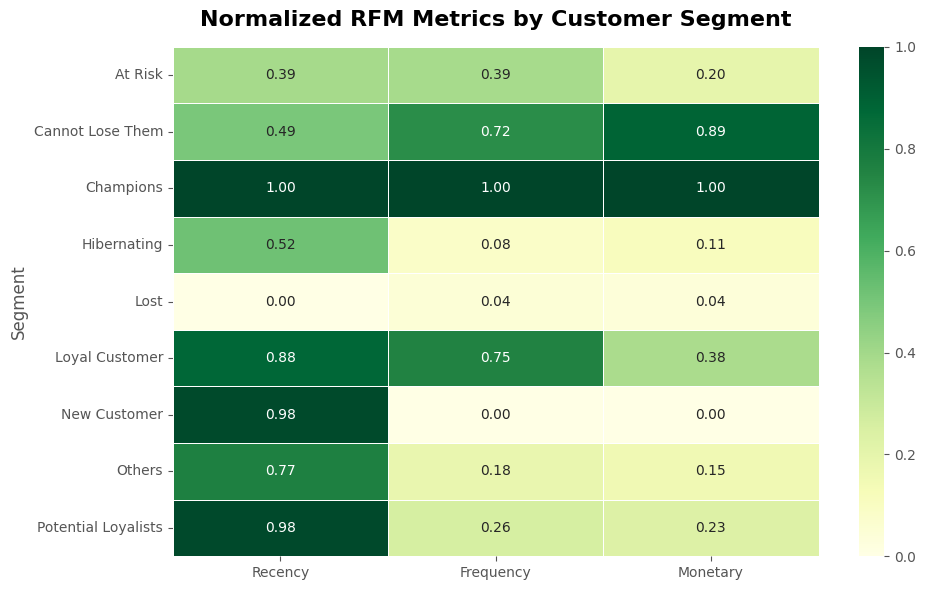

In [38]:
segment_rfm = (
    customer_df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
)

heatmap_data = segment_rfm.copy()

heatmap_data['Recency'] = (
    heatmap_data['Recency'].max()
    - heatmap_data['Recency']
)

scaler = MinMaxScaler()

heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    columns=heatmap_data.columns,
    index=heatmap_data.index
)

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    heatmap_scaled,
    annot=True,
    cmap='YlGn',
    linewidths=0.5,
    fmt='.2f',
    ax=ax
)

ax.set_title(
    'Normalized RFM Metrics by Customer Segment',
    fontsize= 16,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(
    '../images/Average RFM Metrics by Segment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Top 10 Customers by Revenue

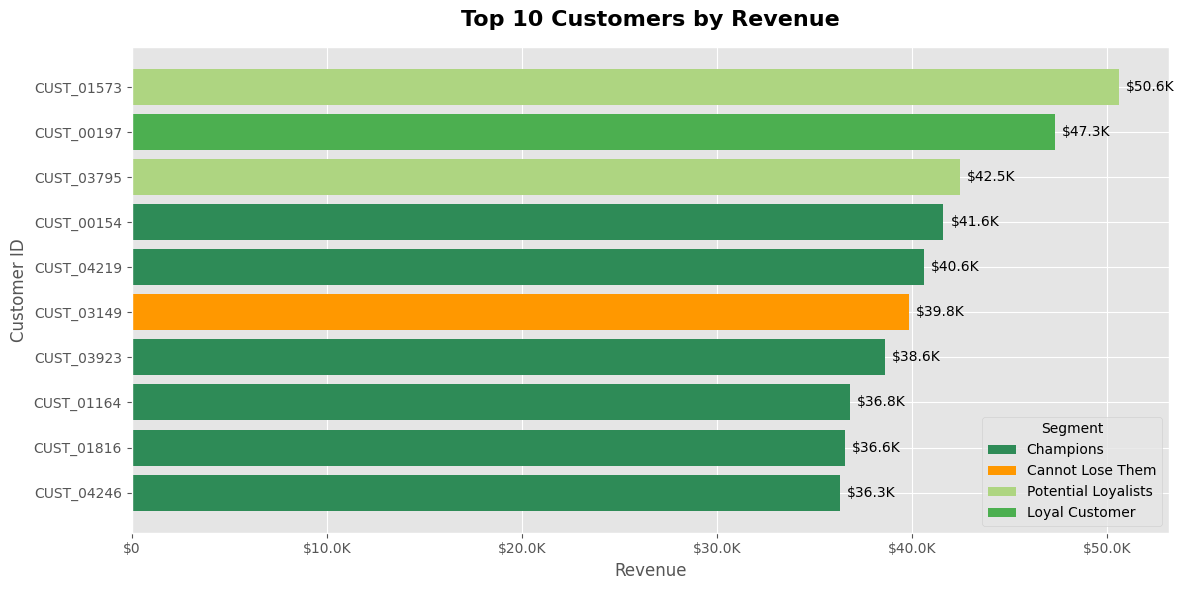

In [39]:
top_customers = (
    customer_df
    .nlargest(10, 'Monetary')
    .sort_values('Monetary')
)

fig, ax = plt.subplots(figsize=(12, 6))

bar_colors = top_customers['Segment'].map(SEGMENT_COLORS)


bars = ax.barh(
    top_customers['Customer_ID'],
    top_customers['Monetary'],
    color=bar_colors
)




labels = [
    format_number(value)
    for value in top_customers['Monetary']
]

ax.bar_label(
    bars,
    labels=labels,
    padding=5
)


ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: format_number(x))
)

top_segments = top_customers['Segment'].unique()

legend_elements =[
    Patch(facecolor=SEGMENT_COLORS[segment], label= segment)
    for segment in top_segments
]

ax.legend(
    handles=legend_elements,
    title='Segment',
    loc='lower right'
)

ax.set_title(
    'Top 10 Customers by Revenue',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Revenue')
ax.set_ylabel('Customer ID')


plt.tight_layout()

plt.savefig(
    '../images/Top 10 Customers by Revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Pareto Analysis

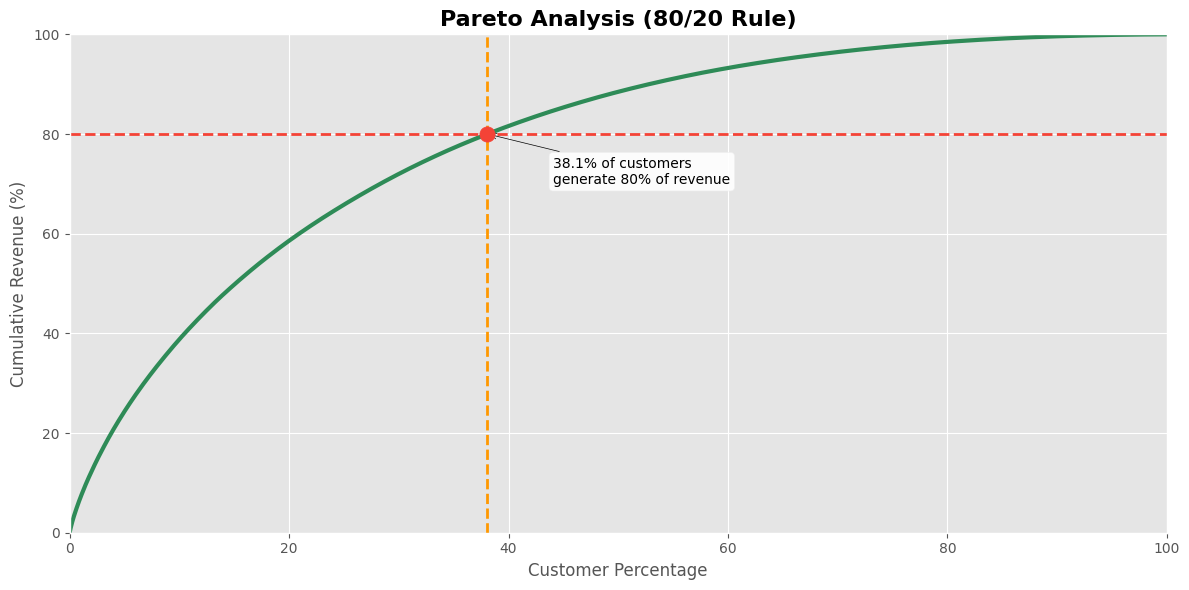

In [41]:
pareto_df= (
    customer_df[['Customer_ID', 'Monetary']].sort_values('Monetary', ascending=False).reset_index(drop=True)
)


pareto_df['Cumulative Revenue'] = pareto_df['Monetary'].cumsum()

pareto_df['Cumulative Revenue %'] = (
    pareto_df['Cumulative Revenue']
    / pareto_df['Monetary'].sum()
) * 100

pareto_df['Customer %'] = (
    (pareto_df.index + 1)
    / len(pareto_df)
) * 100

pareto_80 = pareto_df[
    pareto_df['Cumulative Revenue %'] >= 80
].iloc[0]

customer_percent = pareto_80['Customer %']
revenue_percent = pareto_80['Cumulative Revenue %']

fig, ax = plt.subplots(figsize=(12,6))



ax.plot(
    pareto_df['Customer %'],
    pareto_df['Cumulative Revenue %'],
    color=PRIMARY_COLOR,
    linewidth=3
)

ax.axhline(
    y=80,
    color= DANGER_COLOR,
    linestyle='--',
    linewidth=2
)

ax.axvline(
    x=customer_percent,
    color=WARNING_COLOR,
    linestyle= '--',
    linewidth=2
)

ax.scatter(
    customer_percent,
    revenue_percent,
    color=DANGER_COLOR,
    s=120,
    zorder=5
)

ax.annotate(
    f'{customer_percent:.1f}% of customers \ngenerate 80% of revenue',
    xy=(customer_percent, revenue_percent),
    xytext=(customer_percent + 6, revenue_percent - 10),
    arrowprops=dict(
        arrowstyle='->',
        color='black'
    ),
    fontsize=10,
    bbox=dict(
        boxstyle='round',
        fc='white',
        alpha=0.9
    )
)


ax.set_xlim(0,100)
ax.set_ylim(0,100)

ax.set_xlabel('Customer Percentage')
ax.set_ylabel('Cumulative Revenue (%)')

ax.set_title(
    'Pareto Analysis (80/20 Rule)',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../images/Pareto Analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()